# Linear Algebra for Quantitative Finance

Linear algebra is the backbone of quantitative finance. From portfolio optimization to PCA-based risk models, nearly every quant technique relies on matrix operations.

## What You'll Learn
1. Vectors and matrices — the language of portfolios
2. Matrix operations — returns, covariance, transformations
3. Eigenvalues & eigenvectors — understanding risk structure
4. Principal Component Analysis (PCA) — dimensionality reduction for yield curves and returns
5. Singular Value Decomposition (SVD) — applications in finance

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Vectors as Portfolios

A portfolio of $n$ assets can be represented as a weight vector:

$$\mathbf{w} = \begin{bmatrix} w_1 \\ w_2 \\ \vdots \\ w_n \end{bmatrix}$$

where $w_i$ is the fraction of capital allocated to asset $i$, and $\sum w_i = 1$.

### Portfolio Return
If $\mathbf{r}$ is the vector of asset returns:
$$r_p = \mathbf{w}^T \mathbf{r} = \sum_{i=1}^n w_i r_i$$

In [5]:
# Example: 4-asset portfolio
assets = ['AAPL', 'GOOGL', 'MSFT', 'AMZN']
weights = np.array([0.25, 0.25, 0.30, 0.20])  # portfolio weights
returns = np.array([0.02, -0.01, 0.015, 0.03])  # daily returns

# Portfolio return = dot product
portfolio_return = weights @ returns  # or np.dot(weights, returns)
print(f"Portfolio return: {portfolio_return:.4f} ({portfolio_return*100:.2f}%)")
print(f"Weights sum to: {weights.sum():.2f}")

Portfolio return: 0.0130 (1.30%)
Weights sum to: 1.00


## 2. Covariance Matrix

The covariance matrix $\Sigma$ captures how assets move together:

$$\Sigma = \begin{bmatrix} \sigma_1^2 & \sigma_{12} & \cdots & \sigma_{1n} \\ \sigma_{21} & \sigma_2^2 & \cdots & \sigma_{2n} \\ \vdots & \vdots & \ddots & \vdots \\ \sigma_{n1} & \sigma_{n2} & \cdots & \sigma_n^2 \end{bmatrix}$$

### Portfolio Variance
$$\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w}$$

This is the **quadratic form** — fundamental to Markowitz portfolio optimization.

为什么你可能会觉得“先有相关性”？这通常是因为在构建模型（Model Building）或压力测试时，我们会手动设定相关性：场景 A (回测/实证)： 收益率数据 $\rightarrow$ 协方差矩阵 $\rightarrow$ 相关系数矩阵。（这是从底层向上的逻辑）场景 B (风险模拟)： 风险经理预测“如果未来相关性上升到 0.8 会怎样”。此时你是先设定 $R$，再结合预测的波动率 $D$，人工合成协方差矩阵 $\Sigma = D R D$。（这是从顶层向下的逻辑）


在量化实践中，流程通常是相反的：我们先从原始数据中得到协方差矩阵，然后再通过它导出相关系数矩阵。1. 为什么先有协方差？(The Natural Order)在量化领域，我们最先接触到的是资产的收益率序列 (Returns)。原始数据： 假设你有两只股票 $X$ 和 $Y$ 的收益率数据。协方差 (Covariance)： 它是通过原始收益率直接计算出来的。它反映了两个变量如何“共同变化”：$$\text{Cov}(X, Y) = E[(X - \mu_X)(Y - \mu_Y)]$$直观理解： 如果 $X$ 涨的时候 $Y$ 也涨，这个值就是正的。它的单位是“收益率的平方”，很难直接解释。方差 (Variance)： 也是直接算出来的，即 $\text{Cov}(X, X)$。总结： 协方差矩阵是**“生数据”**，它包含了波动的幅度和方向，没有经过任何人为加工。


In [ ]:
# Simulate 252 days of returns for 4 assets
n_days = 252
n_assets = 4

# Create correlated returns using Cholesky decomposition
mean_returns = np.array([0.0005, 0.0003, 0.0004, 0.0006])  # daily mean
volatilities = np.array([0.02, 0.018, 0.015, 0.025])        # daily vol

# Correlation matrix
corr_matrix = np.array([
    [1.0,  0.6,  0.7,  0.5],
    [0.6,  1.0,  0.65, 0.4],
    [0.7,  0.65, 1.0,  0.55],
    [0.5,  0.4,  0.55, 1.0]
])

# Convert correlation to covariance: Σ = D * C * D where D = diag(σ)
D = np.diag(volatilities)
cov_matrix = D @ corr_matrix @ D

# Generate correlated returns via Cholesky
# cov_matrix = L L.T -> this means any Z~N(0,I), X=Z*L.T will have convariance: cov_matrix
L = np.linalg.cholesky(cov_matrix)
Z = np.random.randn(n_days, n_assets)
simulated_returns = Z @ L.T + mean_returns

returns_df = pd.DataFrame(simulated_returns, columns=assets)
print("Sample Covariance Matrix:")
print(returns_df.cov())
print("\nCorrelation Matrix:")
print(returns_df.corr())
# re should find the similar correlation as we fed in the begining. this comes from cov and vol

Sample Covariance Matrix:
           AAPL     GOOGL      MSFT      AMZN
AAPL   0.000355  0.000193  0.000177  0.000218
GOOGL  0.000193  0.000322  0.000143  0.000140
MSFT   0.000177  0.000143  0.000189  0.000181
AMZN   0.000218  0.000140  0.000181  0.000647

Correlation Matrix:
           AAPL     GOOGL      MSFT      AMZN
AAPL   1.000000  0.571646  0.684917  0.456029
GOOGL  0.571646  1.000000  0.580915  0.305937
MSFT   0.684917  0.580915  1.000000  0.518805
AMZN   0.456029  0.305937  0.518805  1.000000


In [15]:
# Portfolio variance using the quadratic form
sample_cov = returns_df.cov().values
port_variance = weights @ sample_cov @ weights
port_vol = np.sqrt(port_variance)
annualized_vol = port_vol * np.sqrt(252)

print(f"Daily portfolio variance: {port_variance:.8f}")
print(f"Daily portfolio volatility: {port_vol:.4f}")
print(f"Annualized volatility: {annualized_vol:.4f} ({annualized_vol*100:.2f}%)")

Daily portfolio variance: 0.00021502
Daily portfolio volatility: 0.0147
Annualized volatility: 0.2328 (23.28%)


## 3. Eigenvalues & Eigenvectors

For a square matrix $A$, an eigenvector $\mathbf{v}$ and eigenvalue $\lambda$ satisfy:

$$A\mathbf{v} = \lambda\mathbf{v}$$

### Why This Matters in Finance
- **Eigenvalues of the covariance matrix** = variance explained by each principal component
- **Eigenvectors** = the directions of maximum variance (risk factors)
- **Condition number** = ratio of largest to smallest eigenvalue → measures how "well-behaved" the covariance matrix is

In [12]:
# Eigendecomposition of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(sample_cov)

# Sort by eigenvalue (descending)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues (variance explained by each PC):")
for i, ev in enumerate(eigenvalues):
    pct = ev / eigenvalues.sum() * 100
    print(f"  PC{i+1}: {ev:.8f} ({pct:.1f}%)")

print(f"\nCondition number: {eigenvalues[0]/eigenvalues[-1]:.2f}")
print(f"Total variance: {eigenvalues.sum():.8f}")
print(f"Sum of diagonal of cov: {np.trace(sample_cov):.8f}")

Eigenvalues (variance explained by each PC):
  PC1: 0.00094119 (65.8%)
  PC2: 0.00027037 (18.9%)
  PC3: 0.00014348 (10.0%)
  PC4: 0.00007476 (5.2%)

Condition number: 12.59
Total variance: 0.00142981
Sum of diagonal of cov: 0.00142981


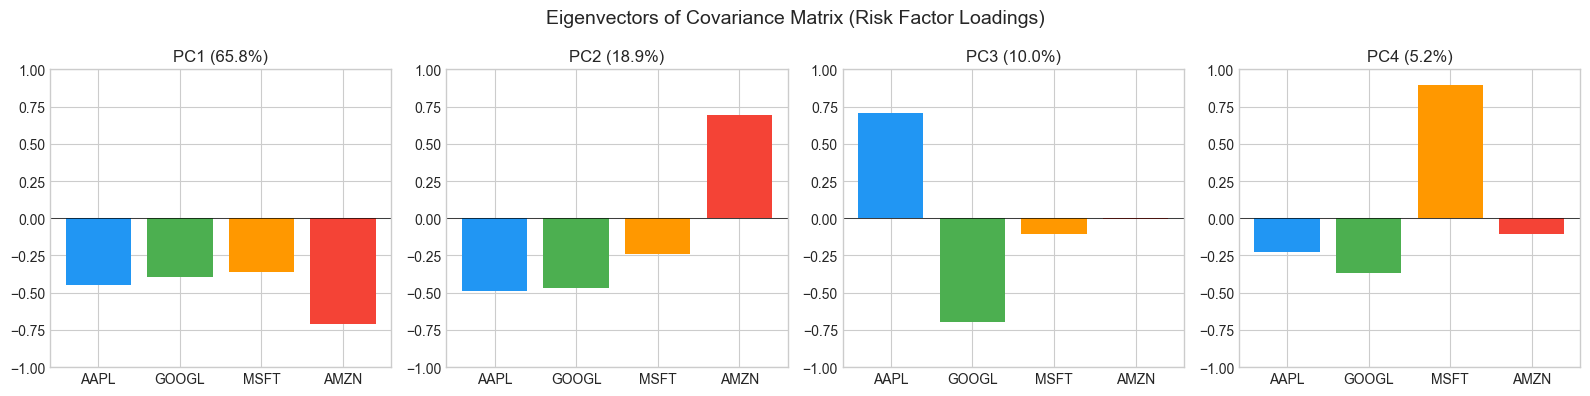

In [13]:
# Visualize eigenvectors as portfolio loadings
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    axes[i].bar(assets, eigenvectors[:, i], color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
    axes[i].set_title(f'PC{i+1} ({eigenvalues[i]/eigenvalues.sum()*100:.1f}%)')
    axes[i].set_ylim(-1, 1)
    axes[i].axhline(y=0, color='black', linewidth=0.5)
plt.suptitle('Eigenvectors of Covariance Matrix (Risk Factor Loadings)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Principal Component Analysis (PCA)

PCA finds the orthogonal directions that explain the most variance in the data.

### Applications in Finance
- **Yield curve modeling**: First 3 PCs explain ~99% of yield curve movements (level, slope, curvature)
- **Risk factor decomposition**: Identify dominant market drivers
- **Dimensionality reduction**: Reduce large asset universes to manageable factor sets
- **Noise filtering**: Remove low-variance components from covariance estimates

In [ ]:
# PCA on returns
pca = PCA()
pca.fit(returns_df)

# Explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(range(1, n_assets + 1), pca.explained_variance_ratio_ * 100, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title('Scree Plot')

cumulative = np.cumsum(pca.explained_variance_ratio_) * 100
ax2.plot(range(1, n_assets + 1), cumulative, 'o-', color='coral')
ax2.axhline(y=95, color='gray', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Variance Explained')
ax2.legend()
plt.tight_layout()
plt.show()

print("Components needed for 95% variance:", np.argmax(cumulative >= 95) + 1)

## 5. Cholesky Decomposition

For a positive definite matrix $\Sigma$, the Cholesky decomposition finds lower triangular $L$ such that:

$$\Sigma = LL^T$$

### Key Use: Generating Correlated Random Variables
If $\mathbf{Z} \sim N(0, I)$ (independent standard normals), then:
$$\mathbf{X} = L\mathbf{Z} \sim N(0, \Sigma)$$

This is essential for **Monte Carlo simulation** of correlated asset returns.

In [ ]:
# Monte Carlo: simulate 10,000 correlated return scenarios
n_simulations = 10000
L = np.linalg.cholesky(cov_matrix)
Z = np.random.randn(n_simulations, n_assets)
correlated_returns = Z @ L.T + mean_returns

# Portfolio returns under each scenario
portfolio_returns = correlated_returns @ weights

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(portfolio_returns * 100, bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(x=np.percentile(portfolio_returns * 100, 5), color='red', linestyle='--', label=f'5% VaR: {np.percentile(portfolio_returns * 100, 5):.3f}%')
ax.axvline(x=np.mean(portfolio_returns * 100), color='green', linestyle='--', label=f'Mean: {np.mean(portfolio_returns * 100):.3f}%')
ax.set_xlabel('Daily Portfolio Return (%)')
ax.set_ylabel('Density')
ax.set_title('Monte Carlo Simulation of Portfolio Returns')
ax.legend()
plt.show()

## 6. Matrix Inversion & Pseudo-Inverse

Matrix inversion is needed for:
- **Markowitz optimization**: $\mathbf{w}^* = \frac{\Sigma^{-1}\boldsymbol{\mu}}{\mathbf{1}^T\Sigma^{-1}\boldsymbol{\mu}}$
- **Linear regression**: $\hat{\beta} = (X^TX)^{-1}X^T\mathbf{y}$

### Pitfall: Ill-Conditioned Matrices
When $n_{assets} \gg n_{observations}$, the sample covariance is singular or near-singular.
Solutions: shrinkage estimators (Ledoit-Wolf), PCA-based covariance, pseudo-inverse.

In [ ]:
# Markowitz tangent portfolio (maximum Sharpe ratio)
mu = returns_df.mean().values  # expected returns
Sigma = returns_df.cov().values  # covariance
Sigma_inv = np.linalg.inv(Sigma)
ones = np.ones(n_assets)

# Tangent portfolio weights (assuming risk-free rate = 0)
w_tangent = Sigma_inv @ mu
w_tangent = w_tangent / w_tangent.sum()  # normalize to sum to 1

print("Tangent Portfolio Weights:")
for asset, w in zip(assets, w_tangent):
    print(f"  {asset}: {w:.4f} ({w*100:.1f}%)")

tang_ret = w_tangent @ mu * 252
tang_vol = np.sqrt(w_tangent @ Sigma @ w_tangent * 252)
print(f"\nAnnualized Return: {tang_ret*100:.2f}%")
print(f"Annualized Vol: {tang_vol*100:.2f}%")
print(f"Sharpe Ratio: {tang_ret/tang_vol:.2f}")

## Exercises

1. **Portfolio math**: Given 5 assets with equal weights, compute the portfolio return and volatility using matrix operations.
2. **Eigenvalue analysis**: Generate a covariance matrix for 10 correlated assets. How many PCs explain 90% of variance?
3. **Cholesky simulation**: Simulate 1-year of daily returns for a 3-asset portfolio. Plot the cumulative returns.
4. **Ill-conditioning**: Create a near-singular covariance matrix (e.g., by making two assets nearly identical). Observe the condition number and the instability of the inverse.
5. **Minimum variance portfolio**: Find the portfolio $\mathbf{w}$ that minimizes $\mathbf{w}^T\Sigma\mathbf{w}$ subject to $\mathbf{1}^T\mathbf{w} = 1$.